# Imports and reads

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, BaseCrossValidator
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso, LassoCV
import matplotlib.pyplot as plt
from utils.data_loader import load_parquet

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay', '|avg B|', 'F10.7 (LASP)']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 4)
                 time  orbital_decay   |avg B|  F10.7 (LASP)
0 2023-01-01 00:00:00        16.6730  5.630000         153.0
1 2023-01-01 00:00:20        16.6730  5.633333         153.0
2 2023-01-01 00:00:40        16.6735  5.636667         153.0
3 2023-01-01 00:01:00        16.6740  5.640000         153.0
4 2023-01-01 00:01:20        16.6740  5.633333         153.0


In [2]:
df = GFOC_data.copy()
time = df['time'].values

# make 'time' the index
df.set_index('time', inplace=True)

# BASE_PATH = '/Users/vanessa/PhD/Dev/SELAnalysis/SpaceWeatherImpact/data/2023-01-01_2024-12-31/processed/'
# df = pd.read_parquet(BASE_PATH + 'SWMA_RDAWFI.parquet', columns=['orbital_decay', '|avg B|', 'F10.7 (LASP)'])
df.index = pd.to_datetime(df.index)
df = df[df.index > pd.Timestamp('2024-05-04')]
df = df.resample('30s').mean()
df['num_index'] = df.reset_index().index

np.random.seed(42)

## Fixed rolling splits

In [3]:
class FixedRollingSplit(BaseCrossValidator):
    def __init__(self, train_size, n_splits=None, step=None, test_size=None, fixed_test_to_end=False, start=0):
        self.n_splits = n_splits
        self.train_size = train_size
        self.test_size = test_size
        self.step = step or test_size
        self.fixed_test_to_end = fixed_test_to_end
        self.start = start

    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        start = self.start
        if self.n_splits is None:
            self.n_splits = n_samples // self.step

        if self.test_size is None:
            self.test_size = n_samples - self.train_size - start

        if start + self.train_size + self.test_size > n_samples:
            raise ValueError(f"Train size + test size + start must be less than the number of samples ({n_samples}). train : {self.train_size}, test : {self.test_size}, start : {start}, n_samples : {n_samples})")

        actual_n_splits = 0
        for i in range(self.n_splits):
            if start + self.train_size > n_samples:
                actual_n_splits = i
                break

            train_start = start
            train_end = train_start + self.train_size

            if not self.fixed_test_to_end:
                test_start = train_end
                test_end = test_start + self.test_size
            else:
                test_start = n_samples - self.test_size
                test_end = n_samples

            if (test_start < train_end) or (test_end > n_samples):
                actual_n_splits = i
                break

            yield np.arange(train_start, train_end), np.arange(test_start, test_end)
            start += self.step
            actual_n_splits += 1

        self.n_splits = actual_n_splits

    def get_n_splits(self, x=None, y=None, groups=None):
        return self.n_splits

## Utils for lags

In [4]:
def make_lags(df, lag_config, lead_time=1):
    out = {}

    for col, params in lag_config.items():
        n_lags = params.get('lags', 1)

        for i in n_lags:
            out[f"{col}_lag_{i}"] = df[col].shift(i)

    return pd.DataFrame(out)

## Create lags, split

In [5]:
period = int(94.5 * 2) # 94.5 minutes in 30s steps
lags = list(range(1, 1*period, 1)) + list(range(1*period, 8*period, 30)) + list(range(8*period, 16*period, 60)) + list(range(16*period, 32*period, period))


lag_config = {
    'orbital_decay': {'lags': lags},
    '|avg B|': {'lags': lags},
    'F10.7 (LASP)': {'lags': lags}
}

X = make_lags(df, lag_config)

# one point forecast (1 orbital period)
y_orig = df['orbital_decay'].copy()
y_shift = y_orig.shift(-period)
y = y_shift - y_orig

# Shifting has created indexes that don't match. Only keep times for
na_mask = X.isna().any(axis=1) | y.isna()
X = X[~na_mask]
y = y[~na_mask]

# Rename columns to avoid MultiIndex issues
X.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else str(col) for col in X.columns]

In [6]:
hour = 60*2
train_size, test_size = 5*24*hour, 6*hour
splitter = FixedRollingSplit(train_size=train_size,
                             test_size=test_size,
                             step=test_size)
splits = list(splitter.split(X, y))

# Simple Feature selection

In [7]:
# from sklearn.feature_selection import mutual_info_regression

# train_idx, test_idx = splits[0]
# X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
# y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

# mi = mutual_info_regression(X_train, y_train)
# top_idx = np.argsort(mi)[::-1][:200]
# X_reduced = X_train.iloc[:, top_idx]

# Find important features across different subsets

In [ ]:
from tqdm import tqdm
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import SequentialFeatureSelector

# pipeline = make_pipeline(StandardScaler(), Lasso(alpha=1e-1))
pipeline = make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-2, 0, 20), cv=5))

# Store feature activity
coef_activity = pd.DataFrame(0, index=X.columns, columns=[f"split_{i}" for i in range(len(splits))])
active_features = {}
median_date = []
train_R2 = []
test_R2 = []
alpha = []

for i, (train_idx, test_idx) in enumerate(tqdm(splits[:5], desc="Rolling splits")):
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

    pipeline.fit(X_train, y_train)

    # make predictions
    y_fit = pipeline.predict(X_train)
    y_pred = pipeline.predict(X_test)
    # score metrics
    train_R2.append(r2_score(y_train, y_fit))
    test_R2.append(r2_score(y_test, y_pred))

    if 'lasso' in pipeline.named_steps:
        lasso = pipeline.named_steps['lasso']
        best_alpha = pipeline.named_steps['lasso'].alpha
    else:
        lasso = pipeline.named_steps['lassocv']
        best_alpha = pipeline.named_steps['lassocv'].alpha_
        print(f"Best alpha: {best_alpha:.4e}")

    feature_strength = np.abs(lasso.coef_)

    # Mark features that are nonzero
    coef_activity.loc[:, f"split_{i}"] = (feature_strength > 0).astype(int)
    active_features[i] = (feature_strength > 0).sum()
    median_date.append(y_train.index[int(len(X_train) // 2)])
    alpha.append(best_alpha)

# Compute how often each feature was active
feature_consistency = coef_activity.mean(axis=1).sort_values(ascending=False)

# Top consistently active features
top_features = feature_consistency.head(20)
print(top_features)

# create Dataframe for active features, train_R2 and test_R2 using median_date as index
results_df = pd.DataFrame.from_dict(active_features, orient='index', columns=['active_features'])
results_df['median_date'] = median_date
results_df['train_R2'] = train_R2
results_df['test_R2'] = test_R2
results_df['alpha'] = alpha
results_df.set_index('median_date', inplace=True)

# save to csv
# feature_consistency.to_csv('Analysis/modeling/feature_consistency2.csv')
# coef_activity.to_csv('Analysis/modeling/coef_activity2.csv')
# results_df.to_csv('Analysis/modeling/results2.csv')

Rolling splits:  20%|██        | 1/5 [00:38<02:32, 38.17s/it]/home/dschwarz/anaconda3/envs/mt_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.069e+01, tolerance: 2.762e+01
  model = cd_fast.enet_coordinate_descent(
Rolling splits: 100%|██████████| 5/5 [04:03<00:00, 48.64s/it]

|avg B|_lag_37           0.005325
|avg B|_lag_19           0.005325
|avg B|_lag_56           0.005325
|avg B|_lag_38           0.005325
|avg B|_lag_39           0.005325
|avg B|_lag_61           0.005325
|avg B|_lag_60           0.005325
|avg B|_lag_59           0.005325
|avg B|_lag_41           0.005325
|avg B|_lag_42           0.005325
|avg B|_lag_36           0.005325
|avg B|_lag_44           0.005325
F10.7 (LASP)_lag_1509    0.005325
|avg B|_lag_45           0.005325
|avg B|_lag_58           0.005325
|avg B|_lag_57           0.005325
|avg B|_lag_50           0.005325
|avg B|_lag_51           0.005325
|avg B|_lag_52           0.005325
|avg B|_lag_53           0.005325
dtype: float64


In [ ]:
# from sklearn.feature_selection import SequentialFeatureSelector

# lasso = Lasso(alpha=best_alpha)
# sfs = SequentialFeatureSelector(
#     lasso,
#     n_features_to_select='auto',
#     direction='backward',
#     scoring='r2',
#     cv=TimeSeriesSplit(n_splits=5)
# )


### load results

In [ ]:
# feature_consistency = pd.read_csv('Analysis/modeling/feature_consistency.csv', index_col=0)
# top_features = feature_consistency.head(20)
# print(top_features)

                               0
orbital_decay_lag_1     1.000000
orbital_decay_lag_70    0.743467
orbital_decay_lag_69    0.734933
orbital_decay_lag_71    0.669333
orbital_decay_lag_68    0.669333
orbital_decay_lag_72    0.619733
orbital_decay_lag_67    0.584000
orbital_decay_lag_73    0.562667
orbital_decay_lag_74    0.517867
orbital_decay_lag_66    0.516800
orbital_decay_lag_65    0.457600
orbital_decay_lag_64    0.418667
orbital_decay_lag_75    0.386133
orbital_decay_lag_63    0.366400
orbital_decay_lag_62    0.307733
orbital_decay_lag_2520  0.285333
orbital_decay_lag_495   0.237867
orbital_decay_lag_61    0.233067
orbital_decay_lag_76    0.224000
orbital_decay_lag_2760  0.198400


# Results

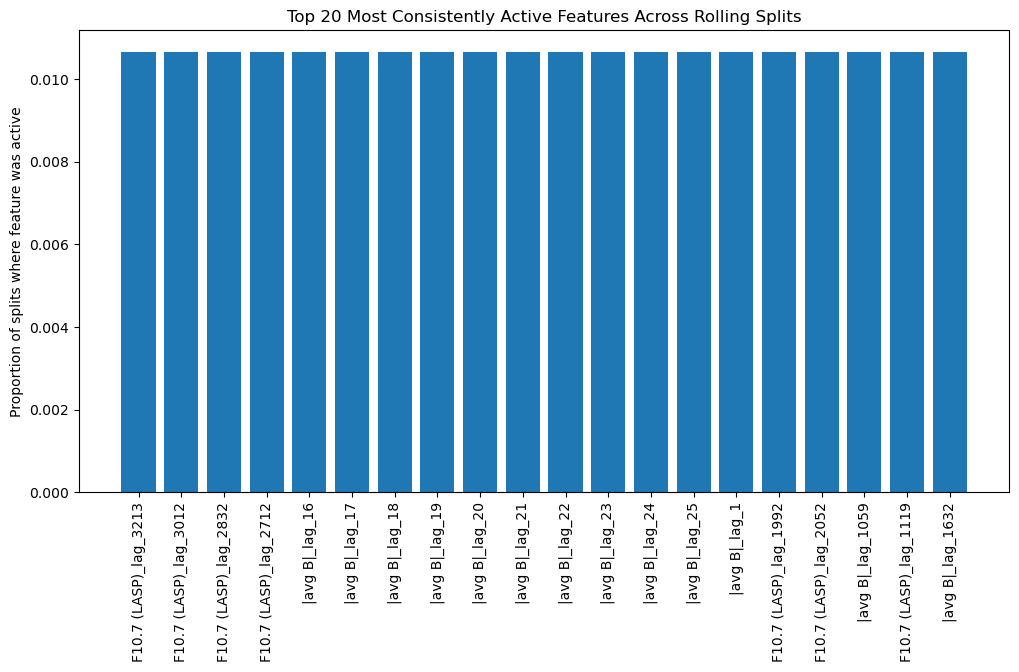

In [11]:
top_features = pd.DataFrame(top_features)

plt.figure(figsize=(12, 6))
plt.bar(top_features.index, top_features.iloc[:, 0].values)
plt.xticks(rotation=90)
plt.ylabel('Proportion of splits where feature was active')
plt.title('Top 20 Most Consistently Active Features Across Rolling Splits')
plt.show()

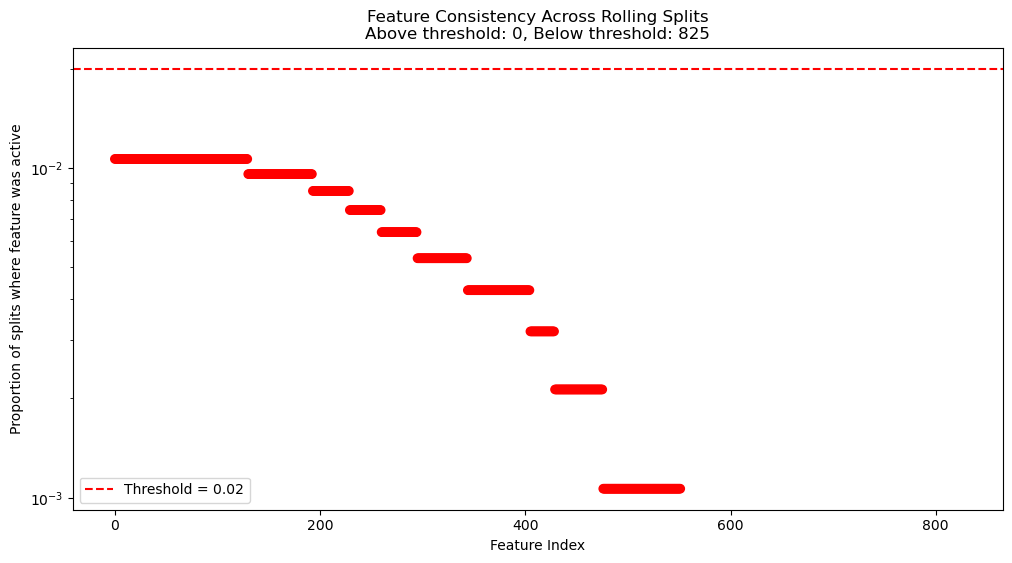

In [ ]:
feature_consistency = pd.DataFrame(feature_consistency)

# Example: feature_consistency is a pandas Series
threshold = 0.02

# Numeric x-axis
a = np.arange(len(feature_consistency))
b = feature_consistency.iloc[:, 0].values

# Color points based on threshold
colors = ['red' if val < threshold else 'blue' for val in b]

# Count features above and below threshold
num_below = np.sum(b < threshold)
num_above = np.sum(b >= threshold)

plt.figure(figsize=(12, 6))
plt.scatter(a, b, c=colors)
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold = {threshold}')
plt.yscale('log')
plt.xlabel('Feature Index')
plt.ylabel('Proportion of splits where feature was active')
plt.title(f'Feature Consistency Across Rolling Splits\nAbove threshold: {num_above}, Below threshold: {num_below}')
# plt.xticks([])  # remove the cluttered x-axis labels
plt.legend()
plt.show()

In [13]:
import re

# Example: feature_consistency is a pandas Series
# feature_consistency = pd.Series(...)

# Filter features by importance threshold
filtered = feature_consistency[feature_consistency > threshold]
filtered = filtered.dropna()

# Extract feature names and lags
feature_names = []
lags = []

for feat in filtered.index:
    match = re.match(r"(.+)_lag_(\d+)", feat)
    if match:
        feature_names.append(match[1])
        lags.append(int(match[2]))
    else:
        feature_names.append(feat)
        lags.append(0)

# Build a DataFrame
df_F = pd.DataFrame({
    'feature': feature_names,
    'lag': lags,
    'importance': filtered.iloc[:, 0].values
})

# Plot each feature separately
features_to_plot = df_F['feature'].unique()

for feature in features_to_plot:
    df_feat = df_F[df_F['feature'] == feature]
    plt.figure(figsize=(8, 4))
    plt.scatter(df_feat['lag'], df_feat['importance'], color='blue')
    plt.title(f"Importance vs Lag for {feature}\n #features: {len(df_feat)}")
    plt.xlabel("Lag")
    plt.ylabel("Importance")
    plt.grid(True)
    plt.show()

    #plot difference
    plt.figure(figsize=(8,4))
    lags = np.sort(df_feat['lag'])
    lag_diff = np.diff(lags)
    plt.plot(lags[:-1], lag_diff, marker = 'o')
    plt.yscale('log')
    plt.title(f"Lag Spacing Evolution for {feature}")
    plt.xlabel("Lag")
    plt.ylabel("Difference to next Lag")
    plt.grid(True)
    plt.show

    # save df_feat['lag'] to list
    lag_list = lags.tolist()
    print(f"Lag list for {feature}: {lag_list}")


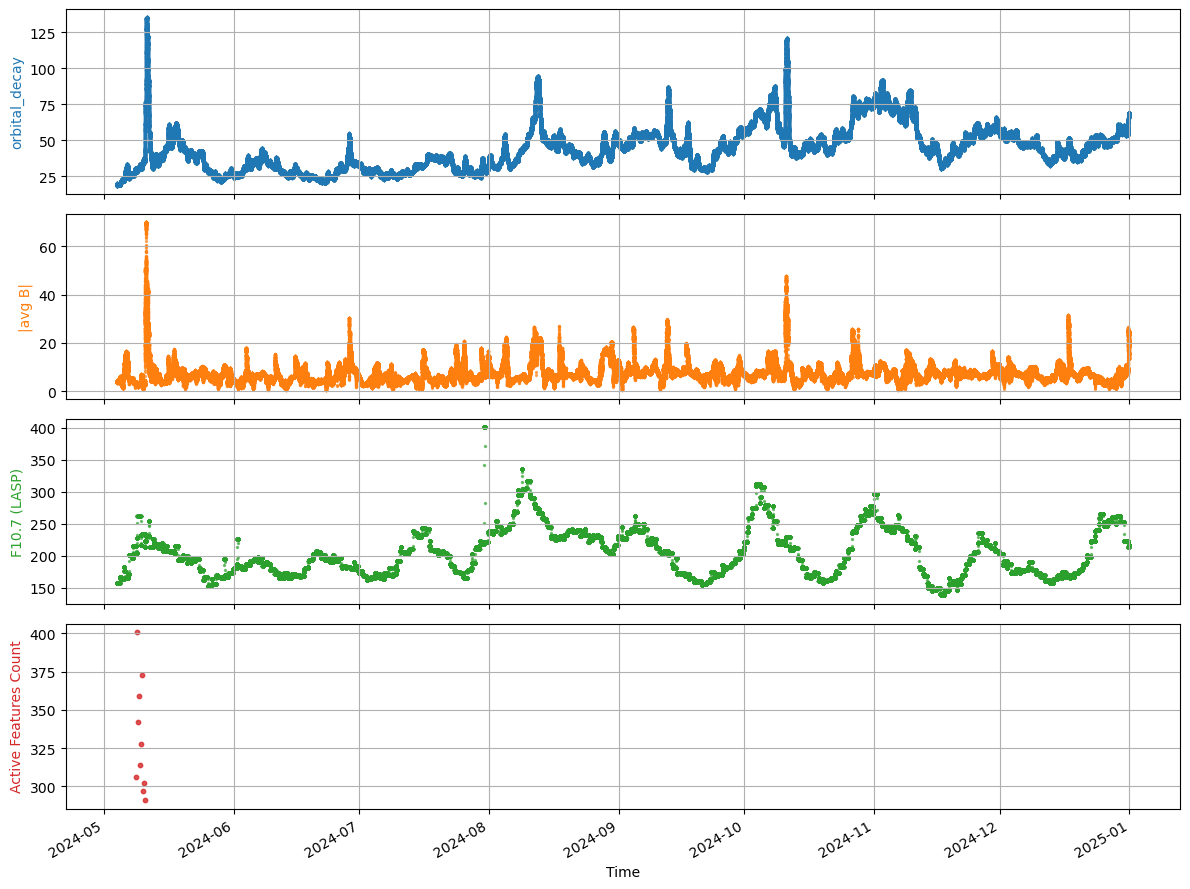

In [14]:
# plot all features from columns_needed
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

axes[0].scatter(df.index, df['orbital_decay'], s=2, c='C0', alpha=0.6)
axes[0].set_ylabel('orbital_decay', color='C0')
axes[0].grid(True)

axes[1].scatter(df.index, df['|avg B|'], s=2, c='C1', alpha=0.6)
axes[1].set_ylabel('|avg B|', color='C1')
axes[1].grid(True)

axes[2].scatter(df.index, df['F10.7 (LASP)'], s=2, c='C2', alpha=0.6)
axes[2].set_ylabel('F10.7 (LASP)', color='C2')
axes[2].set_xlabel('Time')
axes[2].grid(True)

axes[3].scatter(median_date, active_features.values(), s=10, c='C3', alpha=0.8)
axes[3].set_ylabel('Active Features Count', color='C3')
axes[3].set_xlabel('Time')
axes[3].grid(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()